In [1]:
# Shared project setup for imports and file locations
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
FIGURES_DIR = PROJECT_ROOT / "figures"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pdm_learn.modeling import LOOCV_grouped_plot, area_table, heatmap, ks_pvalue
from pdm_learn.oncogene import (
    ONCOGENE_HEATMAP_DIMENSIONS,
    evaluate_method_curves,
    load_oncogene_feature_sets,
    plot_method_curves,
    rank_candidate_oncogenes,
)


In [2]:
data_dict, input_data = load_oncogene_feature_sets(DATA_DIR)
positive, negative = data_dict["PDM"]

pd.DataFrame(
    {
        "dataset": list(data_dict.keys()),
        "positive_genes": [len(value[0]) for value in data_dict.values()],
        "negative_genes": [len(value[1]) for value in data_dict.values()],
    }
)


/Users/jzx/Documents/Computer Science/PDM_Learn/src/pdm_learn/oncogene.py:563: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined = dataset.assign(oncogene=label.to_numpy())


,dataset,positive_genes,negative_genes
0,PDM,62,15243
1,Pearson,62,15006
2,Spearman,62,15006
3,MutualInfo,62,15243
4,Bicor,62,15243


In [3]:
input_data.head()


,gene name,gene_exp.copy_num.0,gene_exp.copy_num.1,gene_exp.copy_num.2,gene_exp.copy_num.3,gene_exp.copy_num.4,gene_exp.copy_num.5,gene_exp.copy_num.6,gene_exp.copy_num.7,gene_exp.copy_num.8,...,gene_mut.CRISPR.5,gene_mut.CRISPR.6,gene_mut.CRISPR.7,gene_mut.CRISPR.8,gene_mut.CRISPR.9,gene_mut.CRISPR.10,gene_mut.CRISPR.11,gene_mut.CRISPR.12,gene_mut.CRISPR.13,oncogene
0,A1BG,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.111943,-5.179541,...,-5.072673,-0.478568,-3.791168,-1.781793,-4.861424,-4.888588,-6.573848,-6.381836,-6.671959,False
1,A1CF,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165493,-7.165489,-7.101136,...,-4.684001,-0.500070,-3.278549,-1.801564,-4.504519,-4.994704,-6.507721,-6.648477,-6.671731,False
2,A2M,-7.165493,-7.163255,-6.911970,-6.646370,-7.136520,-7.165470,-7.165493,-7.165456,-6.973452,...,-4.366357,-0.476633,-3.151028,-1.880186,-4.388499,-5.019282,-6.482807,-6.519536,-6.671790,False
3,A2ML1,-7.165493,-7.164623,-6.992000,-6.602891,-7.111818,-7.165420,-7.165493,-7.165490,-7.117275,...,-3.983835,-0.531421,-2.807655,-1.872339,-4.097288,-4.847229,-6.525058,-6.164724,-6.671956,False
4,A4GALT,-7.165493,-7.165479,-7.140712,-6.429531,-6.142751,-7.062264,-7.165326,-7.157518,-5.725482,...,-5.568323,-0.471883,-4.612959,-1.740518,-5.543676,-4.816489,-6.636474,-6.357813,-6.672016,False


In [4]:
MODEL_LIST = ("SVR", "XGB", "GBR", "MLP", "LR", "GNB")
DEFAULT_MODEL = "XGB"
KS_TEST_BY_METHOD = {"PDM": True}

MODEL_LIST, KS_TEST_BY_METHOD


(('SVR', 'XGB', 'GBR', 'MLP', 'LR', 'GNB'), {'PDM': True})

In [5]:
ranking = rank_candidate_oncogenes(
    positive,
    negative,
    trials=100,
    model=DEFAULT_MODEL,
    ks_test=True,
)
ranking.head(20)


,gene name,score
0,HNF1A,0.993523
1,EBF1,0.992612
2,PIK3R1,0.991284
3,TCF12,0.989674
4,TRPS1,0.988886
5,SOX11,0.987987
6,KAT6A,0.987960
7,HOXB13,0.987571
8,SATB2,0.987314
9,TCF3,0.986429


Running PDM - SVR
Running PDM - XGB
Running PDM - GBR
Running PDM - MLP
Running PDM - LR
Running PDM - GNB
Running Pearson - SVR
Running Pearson - XGB
Running Pearson - GBR
Running Pearson - MLP
Running Pearson - LR
Running Pearson - GNB
Running Spearman - SVR
Running Spearman - XGB
Running Spearman - GBR
Running Spearman - MLP
Running Spearman - LR
Running Spearman - GNB
Running MutualInfo - SVR
Running MutualInfo - XGB
Running MutualInfo - GBR
Running MutualInfo - MLP
Running MutualInfo - LR
Running MutualInfo - GNB
Running Bicor - SVR
Running Bicor - XGB
Running Bicor - GBR
Running Bicor - MLP
Running Bicor - LR
Running Bicor - GNB


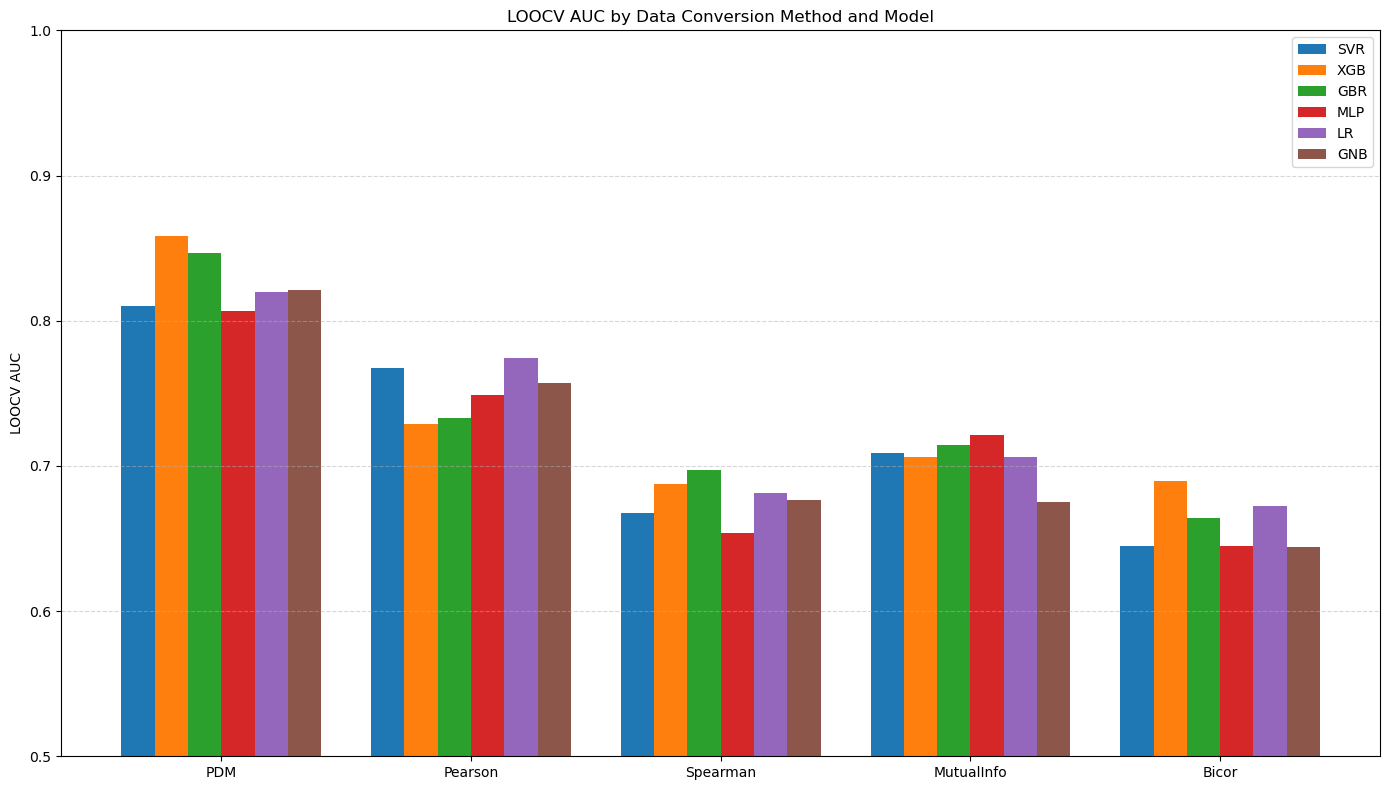

array([[0.80989982, 0.85800865, 0.84655729, 0.80673094, 0.81961491,
        0.82096817],
       [0.76719574, 0.72917262, 0.73266347, 0.74892792, 0.77412799,
        0.75721115],
       [0.66769056, 0.6874824 , 0.69711661, 0.65368634, 0.68103487,
        0.67657996],
       [0.70871459, 0.70607473, 0.71448629, 0.72134356, 0.70607367,
        0.6751477 ],
       [0.644591  , 0.68945265, 0.66386987, 0.64454338, 0.67220842,
        0.6441191 ]])

In [6]:
LOOCV_grouped_plot(
    data_dict,
    5,
    models=MODEL_LIST,
    ks_test=KS_TEST_BY_METHOD,
)


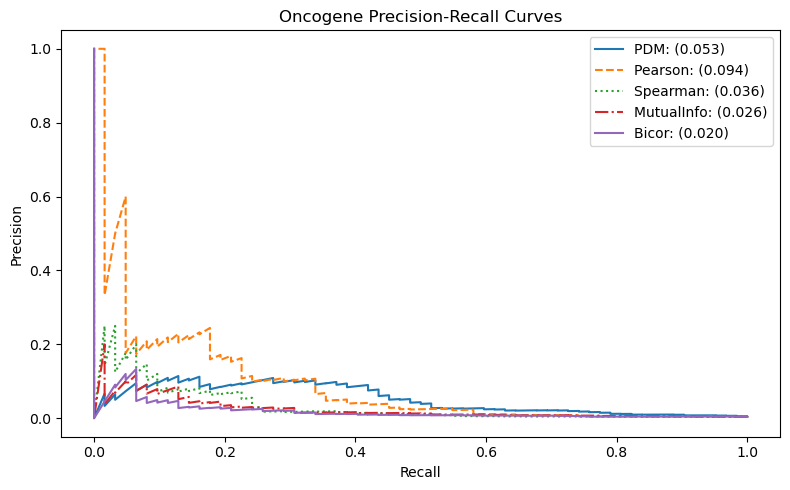

{'PDM': (0.05327078478276058,
  array([1., 1., 1., ..., 0., 0., 0.], shape=(15306,)),
  array([0.00405096, 0.00405123, 0.00405149, ..., 0.        , 0.        ,
         1.        ], shape=(15306,))),
 'Pearson': (0.09437252454042562,
  array([1.        , 1.        , 1.        , ..., 0.01612903, 0.01612903,
         0.        ], shape=(15069,)),
  array([0.00411468, 0.00411495, 0.00411523, ..., 0.5       , 1.        ,
         1.        ], shape=(15069,))),
 'Spearman': (0.03607814886669802,
  array([1., 1., 1., ..., 0., 0., 0.], shape=(15069,)),
  array([0.00411468, 0.00411495, 0.00411523, ..., 0.        , 0.        ,
         1.        ], shape=(15069,))),
 'MutualInfo': (0.026346554607646254,
  array([1., 1., 1., ..., 0., 0., 0.], shape=(15306,)),
  array([0.00405096, 0.00405123, 0.00405149, ..., 0.        , 0.        ,
         1.        ], shape=(15306,))),
 'Bicor': (0.020038707121574482,
  array([1., 1., 1., ..., 0., 0., 0.], shape=(14543,)),
  array([0.00405096, 0.00405123, 0.00

In [7]:
pr_results = evaluate_method_curves(
    data_dict,
    trials=25,
    model=DEFAULT_MODEL,
    ks_test=KS_TEST_BY_METHOD,
    metric="pr",
)
plot_method_curves(
    pr_results,
    title="Oncogene Precision-Recall Curves",
    xlabel="Recall",
    ylabel="Precision",
)
pr_results


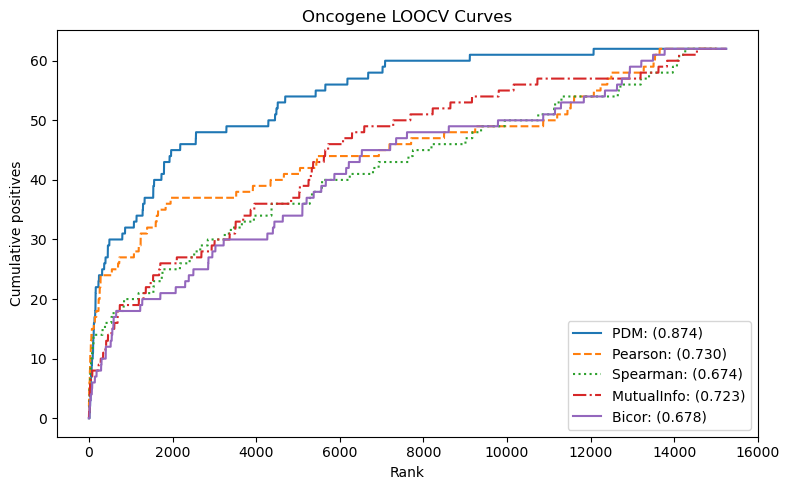

{'PDM': (np.float64(0.8742561854055747),
  array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 1.5241e+04, 1.5242e+04,
         1.5243e+04], shape=(15244,)),
  array([ 0,  0,  0, ..., 62, 62, 62], shape=(15244,))),
 'Pearson': (np.float64(0.7303075768942235),
  array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 1.5004e+04, 1.5005e+04,
         1.5006e+04], shape=(15007,)),
  array([ 2,  2,  3, ..., 62, 62, 62], shape=(15007,))),
 'Spearman': (np.float64(0.6742853335110282),
  array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 1.5004e+04, 1.5005e+04,
         1.5006e+04], shape=(15007,)),
  array([ 0,  0,  0, ..., 62, 62, 62], shape=(15007,))),
 'MutualInfo': (np.float64(0.7231824684063958),
  array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 1.5241e+04, 1.5242e+04,
         1.5243e+04], shape=(15244,)),
  array([ 0,  0,  1, ..., 62, 62, 62], shape=(15244,))),
 'Bicor': (np.float64(0.6777007981987625),
  array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 1.5241e+04, 1.5242e+04,
         1.5243e+04], s

In [8]:
loocv_results = evaluate_method_curves(
    data_dict,
    trials=25,
    model=DEFAULT_MODEL,
    ks_test=KS_TEST_BY_METHOD,
    metric="loocv",
)
plot_method_curves(
    loocv_results,
    title="Oncogene LOOCV Curves",
    xlabel="Rank",
    ylabel="Cumulative positives",
)
loocv_results


In [9]:
feature_arr = [10, 20, 50, 100, 124, 150, 200, 250, 300, 349]
areas = area_table(
    positive.iloc[:, 1:].to_numpy(),
    negative.iloc[:, 1:].to_numpy(),
    20,
    model=DEFAULT_MODEL,
    feat_arr=feature_arr,
)

plt.figure(figsize=(8, 4))
plt.plot(feature_arr, areas, marker="o")
plt.title("PDM Feature Sweep")
plt.xlabel("Selected Features")
plt.ylabel("LOOCV Area")
plt.tight_layout()
plt.show()


10
20
50
100


KeyboardInterrupt: 

In [ ]:
p_val = ks_pvalue(positive.iloc[:, 1:].to_numpy(), negative.iloc[:, 1:].to_numpy())
log_p_val = np.log10(np.clip(p_val, 1e-300, None))
heatmap(
    log_p_val,
    ONCOGENE_HEATMAP_DIMENSIONS,
    cmap="gist_heat_r",
    min=float(np.min(log_p_val)),
    max=float(np.max(log_p_val)),
    flip=True,
    axes=False,
    colorbar=False,
)
